In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

# Load data
data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"

train_data = pd.read_csv(data_path_train)

# Data preprocessing
scaler = MinMaxScaler()
train_data_scaled = scaler.fit_transform(train_data)

# Split validation data into input and output
val_input = train_data_scaled
val_output = train_data_scaled

# Define the autoencoder model
input_dim = train_data_scaled.shape[1]  # Number of features
encoding_dim = 64  # Number of neurons in the bottleneck layer

input_layer = Input(shape=(input_dim,))
encoder_layer = Dense(encoding_dim, activation='relu')(input_layer)
decoder_layer = Dense(input_dim, activation='sigmoid')(encoder_layer)

autoencoder = Model(input_layer, decoder_layer)
autoencoder.compile(optimizer='adam', loss='mse')

# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the autoencoder with early stopping
history = autoencoder.fit(val_input, val_output,
                          epochs=100,
                          batch_size=32,
                          shuffle=True,
                          validation_split=0.1,
                          callbacks=[early_stopping])

# Calculate reconstruction error for validation data
val_predictions = autoencoder.predict(val_input)
reconstruction_error = np.mean(np.square(val_output - val_predictions), axis=1)

# Print reconstruction errors
print("Reconstruction Errors:")
print(reconstruction_error)

# Determine threshold using Median Absolute Deviation (MAD)
median_error = np.median(reconstruction_error)
mad = np.median(np.abs(reconstruction_error - median_error))
threshold = median_error + 3 * mad  # Adjust multiplier as needed

print("Threshold:", threshold)

# Save the trained autoencoder model with the threshold
model_path = "trained_autoencoder_model_with_threshold.h5"
autoencoder.save(model_path)

print("Model saved at:", model_path)


Epoch 1/100
986/986 [==============================] - 3s 3ms/step - loss: 0.0186 - val_loss: 0.0149
Epoch 2/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0094 - val_loss: 0.0055
Epoch 3/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0040 - val_loss: 0.0033
Epoch 4/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0030 - val_loss: 0.0029
Epoch 5/100
986/986 [==============================] - 3s 3ms/step - loss: 0.0027 - val_loss: 0.0028
Epoch 6/100
986/986 [==============================] - 3s 3ms/step - loss: 0.0026 - val_loss: 0.0027
Epoch 7/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0026 - val_loss: 0.0027
Epoch 8/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0025 - val_loss: 0.0027
Epoch 9/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0025 - val_loss: 0.0026
Epoch 10/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0025 - val_lo

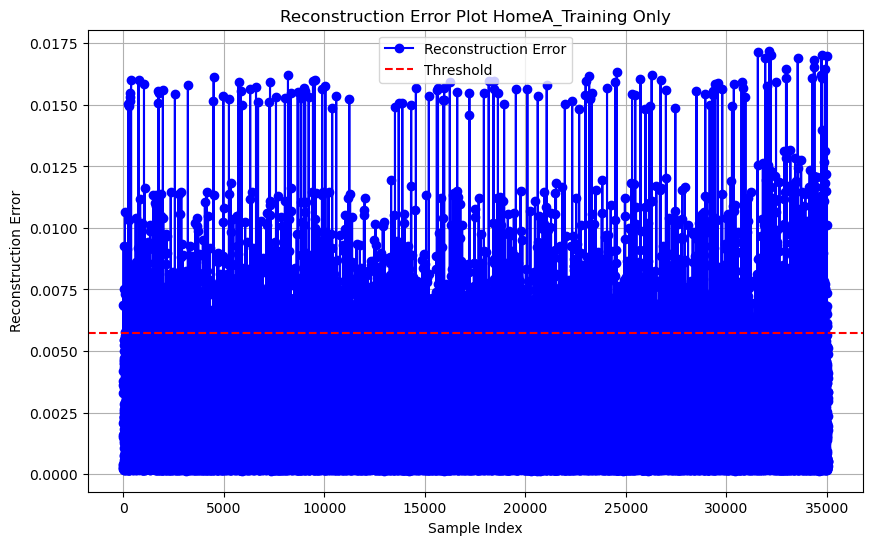

In [5]:
# Plot reconstruction error and threshold
plt.figure(figsize=(10, 6))
plt.plot(reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error Plot HomeA_Training Only')
plt.legend()
plt.grid()

plt.show()

10/10 [==============================] - 0s 1ms/step


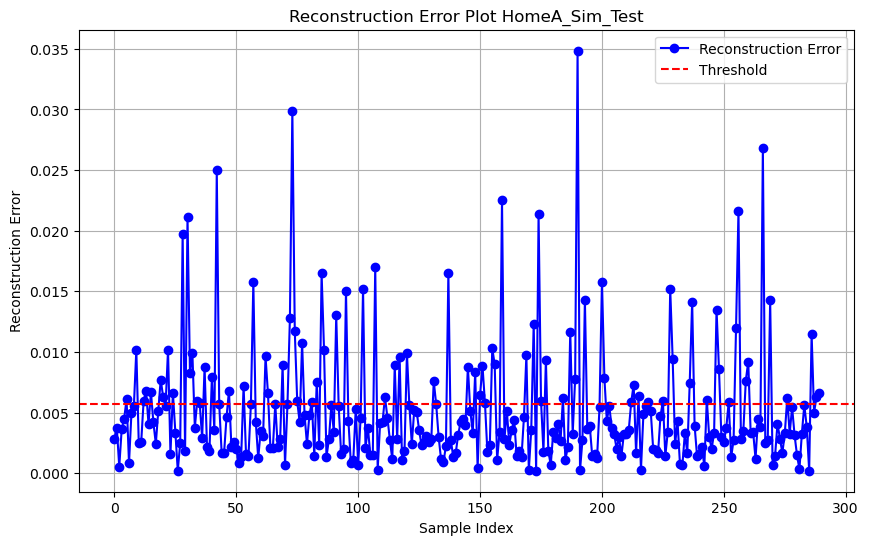

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import load_model

# Load data
data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_sim_test.csv"

train_data = pd.read_csv(data_path_train)
test_data = pd.read_csv(data_path_test)

# Data preprocessing
scaler = MinMaxScaler()
train_data_scaled = scaler.fit_transform(train_data)
test_data_scaled = scaler.transform(test_data)

# Load the trained autoencoder model with the threshold
model_path = "trained_autoencoder_model_with_threshold.h5"
autoencoder = load_model(model_path)

# Calculate reconstruction error for test data
test_predictions = autoencoder.predict(test_data_scaled)
test_reconstruction_error = np.mean(np.square(test_data_scaled - test_predictions), axis=1)

# Plot reconstruction error
plt.figure(figsize=(10, 6))
plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error Plot HomeA_Sim_Test')
plt.legend()
plt.grid()

plt.show()


548/548 [==============================] - 1s 1ms/step


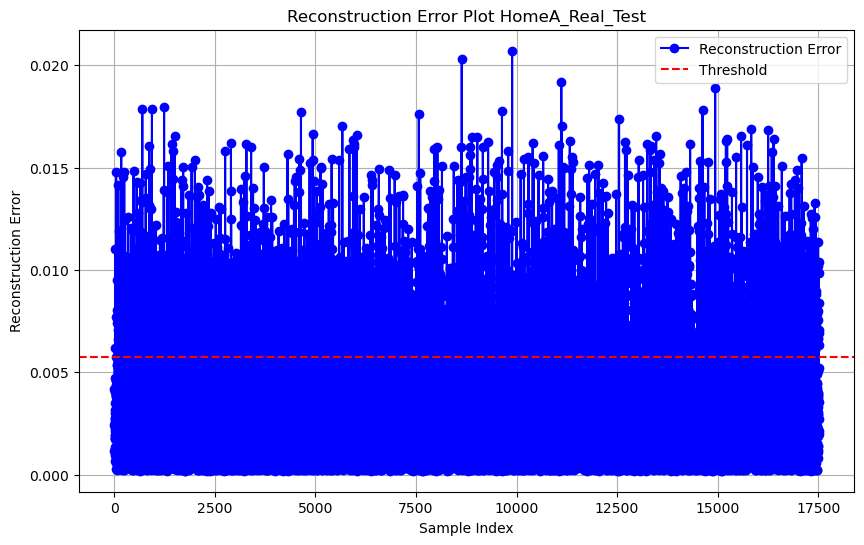

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import load_model

# Load data
data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_real_test.csv"

train_data = pd.read_csv(data_path_train)
test_data = pd.read_csv(data_path_test)

# Data preprocessing
scaler = MinMaxScaler()
train_data_scaled = scaler.fit_transform(train_data)
test_data_scaled = scaler.transform(test_data)

# Load the trained autoencoder model with the threshold
model_path = "trained_autoencoder_model_with_threshold.h5"
autoencoder = load_model(model_path)

# Calculate reconstruction error for test data
test_predictions = autoencoder.predict(test_data_scaled)
test_reconstruction_error = np.mean(np.square(test_data_scaled - test_predictions), axis=1)

# Plot reconstruction error
plt.figure(figsize=(10, 6))
plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error Plot HomeA_Real_Test')
plt.legend()
plt.grid()

plt.show()

10/10 [==============================] - 0s 2ms/step
Threshold: 0.009593841656332864
Anomalous Data Indices:
[  9  22  28  30  32  42  57  62  72  73  74  77  85  86  91  95 102 107
 120 137 155 159 169 172 174 187 190 193 200 228 237 247 255 256 266 269
 286]


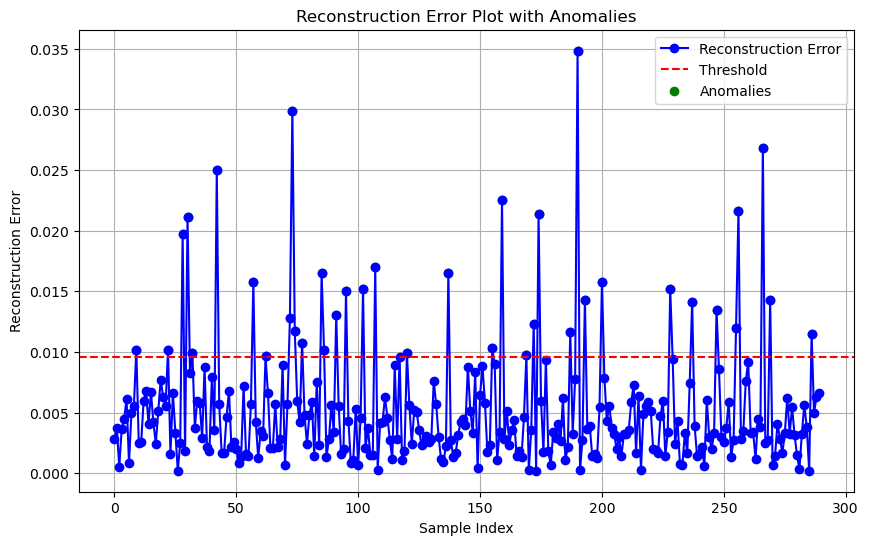

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import load_model

# Load data
data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_sim_test.csv"

train_data = pd.read_csv(data_path_train)
test_data = pd.read_csv(data_path_test)

# Data preprocessing
scaler = MinMaxScaler()
train_data_scaled = scaler.fit_transform(train_data)
test_data_scaled = scaler.transform(test_data)

# Load the trained autoencoder model with the threshold
model_path = "trained_autoencoder_model_with_threshold.h5"
autoencoder = load_model(model_path)

# Calculate reconstruction error for test data
test_predictions = autoencoder.predict(test_data_scaled)
test_reconstruction_error = np.mean(np.square(test_data_scaled - test_predictions), axis=1)

# Determine threshold using Median Absolute Deviation (MAD)
median_error = np.median(test_reconstruction_error)
mad = np.median(np.abs(test_reconstruction_error - median_error))
threshold = median_error + 3 * mad  # Adjust multiplier as needed

print("Threshold:", threshold)

# Classify anomalies based on the threshold
anomalies = test_reconstruction_error > threshold

# Print the indices of anomalous data
print("Anomalous Data Indices:")
anomalous_indices = np.where(anomalies)[0]
print(anomalous_indices)

# Plot reconstruction error with anomalous points highlighted
plt.figure(figsize=(10, 6))
plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices], color='g', label='Anomalies')
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error Plot with Anomalies')
plt.legend()
plt.grid()

plt.show()


Threshold: 0.007211294036830634
Anomalous Data Indices:
[   18    44    47 ... 17510 17516 17519]


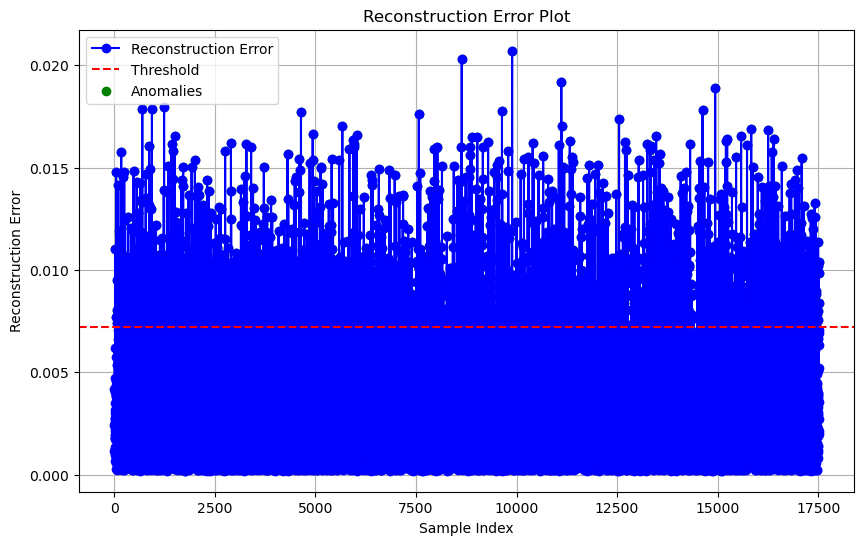

In [8]:
# Determine threshold using Median Absolute Deviation (MAD)
median_error = np.median(test_reconstruction_error)
mad = np.median(np.abs(test_reconstruction_error - median_error))
threshold = median_error + 3 * mad  # Adjust multiplier as needed

print("Threshold:", threshold)

# Classify anomalies based on the threshold
anomalies = test_reconstruction_error > threshold

# Print the indices of anomalous data
print("Anomalous Data Indices:")
anomalous_indices = np.where(anomalies)[0]
print(anomalous_indices)

# Plot reconstruction error with anomalous points highlighted
plt.figure(figsize=(10, 6))
plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices], color='g', label='Anomalies')
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error Plot')
plt.legend()
plt.grid()

plt.show()


Epoch 1/100
986/986 [==============================] - 3s 3ms/step - loss: 0.0185 - val_loss: 0.0143
Epoch 2/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0085 - val_loss: 0.0049
Epoch 3/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0038 - val_loss: 0.0033
Epoch 4/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0030 - val_loss: 0.0030
Epoch 5/100
986/986 [==============================] - 3s 3ms/step - loss: 0.0027 - val_loss: 0.0028
Epoch 6/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0026 - val_loss: 0.0027
Epoch 7/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0026 - val_loss: 0.0027
Epoch 8/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0025 - val_loss: 0.0027
Epoch 9/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0025 - val_loss: 0.0026
Epoch 10/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0025 - val_lo

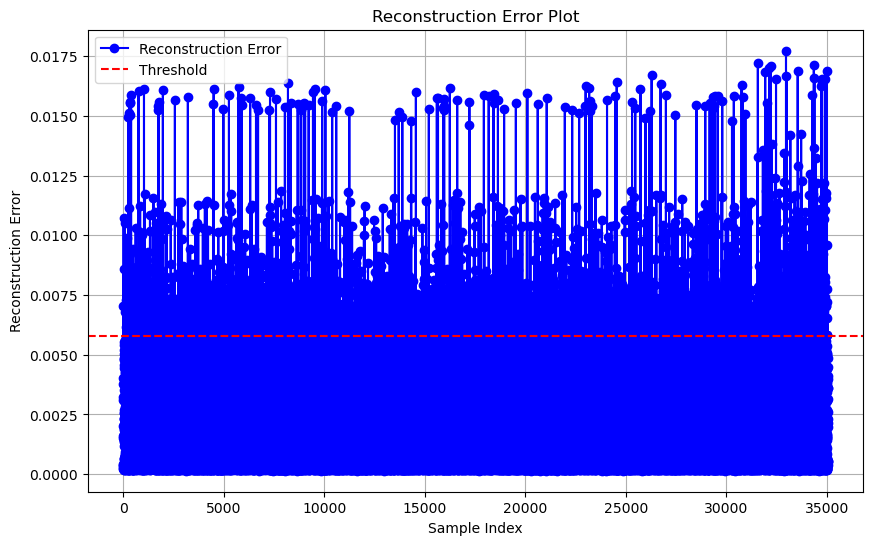

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

# Load data
data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"

train_data = pd.read_csv(data_path_train)

# Data preprocessing
scaler = MinMaxScaler()
train_data_scaled = scaler.fit_transform(train_data)

# Split validation data into input and output
val_input = train_data_scaled
val_output = train_data_scaled

# Define the autoencoder model
input_dim = train_data_scaled.shape[1]  # Number of features
encoding_dim = 64  # Number of neurons in the bottleneck layer

input_layer = Input(shape=(input_dim,))
encoder_layer = Dense(encoding_dim, activation='relu')(input_layer)
decoder_layer = Dense(input_dim, activation='sigmoid')(encoder_layer)

autoencoder = Model(input_layer, decoder_layer)
autoencoder.compile(optimizer='adam', loss='mse')

# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the autoencoder with early stopping
history = autoencoder.fit(val_input, val_output,
                          epochs=100,
                          batch_size=32,
                          shuffle=True,
                          validation_split=0.1,
                          callbacks=[early_stopping])

# Save the trained autoencoder model
autoencoder.save("trained_autoencoder_model.h5")

# Calculate reconstruction error for validation data
val_predictions = autoencoder.predict(val_input)
reconstruction_error = np.mean(np.square(val_output - val_predictions), axis=1)

# Determine threshold using Median Absolute Deviation (MAD)
median_error = np.median(reconstruction_error)
mad = np.median(np.abs(reconstruction_error - median_error))
threshold = median_error + 3 * mad  # Adjust multiplier as needed

print("Threshold:", threshold)

# Print reconstruction errors
print("Reconstruction Errors:")
print(reconstruction_error)

# Plot reconstruction error and threshold
plt.figure(figsize=(10, 6))
plt.plot(reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error Plot')
plt.legend()
plt.grid()

plt.show()


10/10 [==============================] - 0s 1ms/step
Threshold: 0.009797206990370306


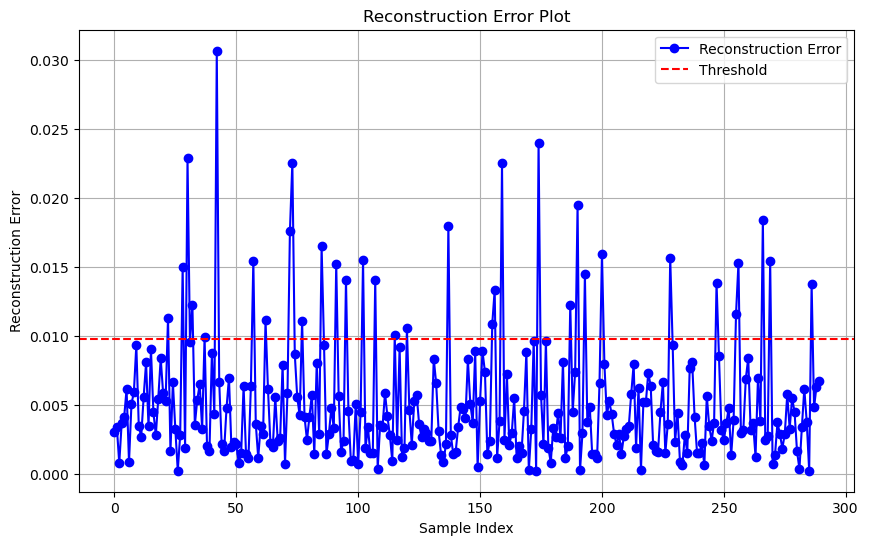

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, precision_recall_curve, roc_curve, auc
from tensorflow.keras.models import load_model

# Load data
data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_sim_test.csv"

train_data = pd.read_csv(data_path_train)
test_data = pd.read_csv(data_path_test)

# Load the trained autoencoder
autoencoder = load_model('trained_autoencoder_model.h5')  # Replace with your actual model filename

# Data preprocessing
scaler = MinMaxScaler()
train_data_scaled = scaler.fit_transform(train_data)
test_data_scaled = scaler.transform(test_data)

# Calculate reconstruction error for test data
test_predictions = autoencoder.predict(test_data_scaled)
reconstruction_error = np.mean(np.square(test_data_scaled - test_predictions), axis=1)

# Print reconstruction errors
# print("Reconstruction Errors:")
# print(reconstruction_error)

# Determine threshold using Median Absolute Deviation (MAD)
median_error = np.median(reconstruction_error)
mad = np.median(np.abs(reconstruction_error - median_error))
threshold = median_error + 3 * mad  # Adjust multiplier as needed

print("Threshold:", threshold)

# Apply threshold and classify samples as normal or anomaly
binary_predictions = (reconstruction_error > threshold).astype(int)
binary_labels = (test_data_scaled > threshold).astype(int)

# Plot reconstruction error and threshold
plt.figure(figsize=(10, 6))
plt.plot(reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error Plot')
plt.legend()
plt.grid()

plt.show()

# # Calculate confusion matrix
# conf_matrix = confusion_matrix(binary_labels.ravel(), binary_predictions)

# # Extract confusion matrix components
# tn, fp, fn, tp = conf_matrix.ravel()

# # Calculate evaluation metrics
# accuracy = (tp + tn) / (tp + tn + fp + fn)
# precision = tp / (tp + fp)
# recall = tp / (tp + fn)
# tnr = tn / (tn + fp)
# fnr = fn / (fn + tp)
# f1_score = 2 * (precision * recall) / (precision + recall)

# # Calculate ROC curve and AUC
# fpr, tpr, _ = roc_curve(binary_labels.ravel(), reconstruction_error)
# roc_auc = auc(fpr, tpr)

# # Plot ROC curve
# plt.figure(figsize=(10, 6))
# plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
# plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver Operating Characteristic (ROC) Curve')
# plt.legend(loc="lower right")
# plt.grid()

# plt.show()

# # Print evaluation metrics
# print("Evaluation Metrics:")
# print("Accuracy:", accuracy)
# print("Precision:", precision)
# print("Recall:", recall)
# print("True Negative Rate (TNR):", tnr)
# print("False Negative Rate (FNR):", fnr)
# print("F1-Score:", f1_score)
# print("AUC-ROC:", roc_auc)


Epoch 1/100
986/986 [==============================] - 3s 2ms/step - loss: 0.0183 - val_loss: 0.0140
Epoch 2/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0087 - val_loss: 0.0052
Epoch 3/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0038 - val_loss: 0.0033
Epoch 4/100
986/986 [==============================] - 3s 3ms/step - loss: 0.0030 - val_loss: 0.0029
Epoch 5/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0027 - val_loss: 0.0027
Epoch 6/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0026 - val_loss: 0.0028
Epoch 7/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0026 - val_loss: 0.0027
Epoch 8/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0026 - val_loss: 0.0027
Epoch 9/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0025 - val_loss: 0.0027
Epoch 10/100
986/986 [==============================] - 2s 2ms/step - loss: 0.0025 - val_lo

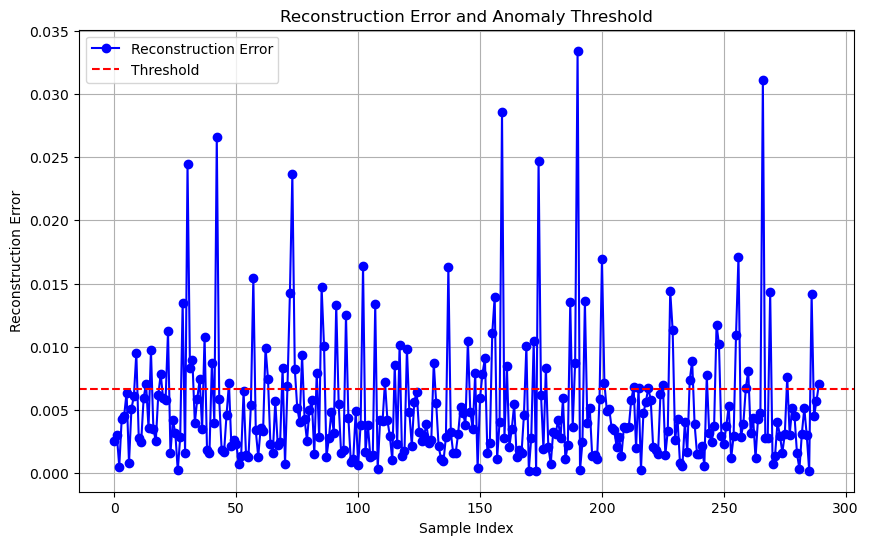

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

# Load data
train_data_path = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_unsupervise_train.csv"
test_data_path = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_A_sim_test.csv"

train_data = pd.read_csv(train_data_path)
test_data = pd.read_csv(test_data_path)

# Data preprocessing
scaler = MinMaxScaler()
train_data_scaled = scaler.fit_transform(train_data)
test_data_scaled = scaler.transform(test_data)

# Define the autoencoder model
input_dim = train_data_scaled.shape[1]  # Number of features
encoding_dim = 64  # Number of neurons in the bottleneck layer

input_layer = Input(shape=(input_dim,))
encoder_layer = Dense(encoding_dim, activation='relu')(input_layer)
decoder_layer = Dense(input_dim, activation='sigmoid')(encoder_layer)

autoencoder = Model(input_layer, decoder_layer)
autoencoder.compile(optimizer='adam', loss='mse')

# Train the autoencoder
autoencoder.fit(train_data_scaled, train_data_scaled,
                epochs=100,
                batch_size=32,
                shuffle=True,
                validation_split=0.1)

# Calculate reconstruction error for test data
test_predictions = autoencoder.predict(test_data_scaled)
reconstruction_error = np.mean(np.square(test_data_scaled - test_predictions), axis=1)

# Apply the specified threshold
threshold = 0.006628391283832475

# Plot reconstruction error
plt.figure(figsize=(10, 6))
plt.plot(reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error and Anomaly Threshold')
plt.legend()
plt.grid()
plt.show()
